#----------------------------------------------------------------------------

# Comparación de Modelos - Predicción de Cancelaciones Hoteleras

#----------------------------------------------------------------------------

Este notebook corresponde al rol de Model Comparator (PB-12).

### El objetivo es evaluar los modelos baseline entrenados previamente, utilizando métricas de clasificación y visualizaciones, alineadas con los objetivos del negocio.

# 1. Cargar datos y modelos

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import os
import joblib

# ========================
# 1. Cargar dataset y modelos
# ========================

import pandas as pd

df = pd.read_csv('../data/interim/hotel_bookings_fe.csv')

print("Shape:", df.shape)

# Modelos
models_path = "../models"

models = {}
for file in os.listdir(models_path):
    if file.startswith("baseline_") and file.endswith(".pkl"):
        name = file.replace("baseline_", "").replace(".pkl", "")
        models[name] = joblib.load(os.path.join(models_path, file))

print("Modelos cargados:", models.keys())

Shape: (86372, 51)
Modelos cargados: dict_keys(['dt', 'gb', 'knn', 'lr', 'svm'])


In [2]:
# ========================
# 2. Distribución del target
# ========================

target_dist = df['is_canceled'].value_counts(normalize=True)

print(target_dist)

is_canceled
0    0.725293
1    0.274707
Name: proportion, dtype: float64


In [3]:
# ========================
# 3. Separar variables
# ========================

X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

In [4]:
# ========================
# 4. Train/Test Split
# ========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (69097, 50)
Test: (17275, 50)


# 2. Cross-validation + Test evaluation

In [5]:
# ========================
# 5. Cross-validation usando la data train original sin balancear
# ========================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.base import clone
import time

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []

print("\n Iniciando evaluación de modelos...\n")

for name, model in models.items():
    
    # Excluir SVM se priorizan otros modelos
    if name == "svm":
        continue    
    # Cross-validation
    print("  Ejecutando cross-validation...")
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    print(" CV completado")

    # ------------------------
    # Entrenamiento limpio (clone)
    # ------------------------
    print("   Entrenando modelo completo...")
    model_clone = clone(model)
    model_clone.fit(X_train, y_train)
    
    # ------------------------
    # Predicciones
    # ------------------------
    y_pred = model_clone.predict(X_test)
    
    # ------------------------
    # Probabilidades / scores para AUC
    # ------------------------
    if hasattr(model_clone, "predict_proba"):
        y_proba = model_clone.predict_proba(X_test)[:, 1]
    elif hasattr(model_clone, "decision_function"):
        y_proba = model_clone.decision_function(X_test)
    else:
        y_proba = None

    auc_test = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    # ------------------------
    # Guardar resultados
    # ------------------------
    results_list.append({
        'Modelo': name,
        
        # CV metrics
        'CV_Accuracy': scores['test_accuracy'].mean(),
        'CV_Precision': scores['test_precision'].mean(),
        'CV_Recall': scores['test_recall'].mean(),
        'CV_F1': scores['test_f1'].mean(),
        'CV_AUC': scores['test_roc_auc'].mean(),
        
        # Test metrics
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Test_Precision': precision_score(y_test, y_pred, zero_division=0),
        'Test_Recall': recall_score(y_test, y_pred, zero_division=0),
        'Test_F1': f1_score(y_test, y_pred, zero_division=0),
        'Test_AUC': auc_test,
        
        # Tiempo
        'Train_Time': scores['fit_time'].mean()
    })

print("\n Consolidando resultados...")



 Iniciando evaluación de modelos...

  Ejecutando cross-validation...
 CV completado
   Entrenando modelo completo...
  Ejecutando cross-validation...
 CV completado
   Entrenando modelo completo...
  Ejecutando cross-validation...
 CV completado
   Entrenando modelo completo...


C:\Users\jorge\miniforge3\envs\dp261-g2\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


  Ejecutando cross-validation...
 CV completado
   Entrenando modelo completo...

 Consolidando resultados...


In [9]:
# ========================
# 6. DataFrame final
# ========================
df_results = pd.DataFrame(results_list)

# ------------------------
# Overfitting check
# ------------------------
df_results['F1_gap'] = df_results['CV_F1'] - df_results['Test_F1']
df_results['Recall_gap'] = df_results['CV_Recall'] - df_results['Test_Recall']

# ------------------------
# Orden final (F1)
# ------------------------
df_results = df_results[[
    'Modelo',
    'CV_F1', 'Test_F1',
    'CV_Recall', 'Test_Recall',
    'CV_AUC', 'Test_AUC',
    'Train_Time',
    'F1_gap', 'Recall_gap'
]].sort_values('CV_Recall', ascending=False)

print(" Evaluación completada\n")

df_results

 Evaluación completada



,Modelo,CV_F1,Test_F1,CV_Recall,Test_Recall,CV_AUC,Test_AUC,Train_Time,F1_gap,Recall_gap
0,dt,0.525384,0.535158,0.528318,0.535609,0.672911,0.678818,0.364633,-0.009773,-0.007291
2,knn,0.507974,0.513661,0.459091,0.465445,0.753084,0.754588,0.078185,-0.005687,-0.006354
1,gb,0.536865,0.543110,0.422370,0.426043,0.828249,0.831489,5.316732,-0.006245,-0.003673
3,lr,0.374303,0.374335,0.262052,0.259376,0.763010,0.765734,0.128554,-0.000032,0.002675


# 3. Ranking

In [10]:
df_results['Rank'] = df_results['CV_Recall'].rank(ascending=False)
df_results.sort_values('Rank')

,Modelo,CV_F1,Test_F1,CV_Recall,Test_Recall,CV_AUC,Test_AUC,Train_Time,F1_gap,Recall_gap,Rank
0,dt,0.525384,0.535158,0.528318,0.535609,0.672911,0.678818,0.364633,-0.009773,-0.007291,1.0
2,knn,0.507974,0.513661,0.459091,0.465445,0.753084,0.754588,0.078185,-0.005687,-0.006354,2.0
1,gb,0.536865,0.543110,0.422370,0.426043,0.828249,0.831489,5.316732,-0.006245,-0.003673,3.0
3,lr,0.374303,0.374335,0.262052,0.259376,0.763010,0.765734,0.128554,-0.000032,0.002675,4.0


# 4. Visualización rápida

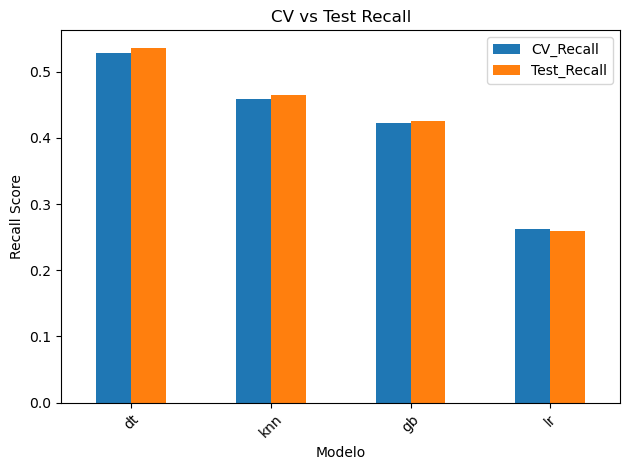

In [11]:
import matplotlib.pyplot as plt

df_plot = df_results.set_index('Modelo')[['CV_Recall', 'Test_Recall']]

df_plot.plot(kind='bar')
plt.title("CV vs Test Recall")
plt.ylabel("Recall Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()